In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('IPL Matches 2008-2020.csv',usecols=['result_margin'])

In [3]:
df.head()

,result_margin
0,140.0
1,33.0
2,9.0
3,5.0
4,5.0


In [4]:
df.isnull().mean()*100

result_margin    2.083333
dtype: float64

In [5]:
# set a fixed random seed
np.random.seed(42)

In [6]:
# Get The Non-Missing values
non_missing_values = df['result_margin'].dropna().values

In [7]:
# Make a new Column  for filled data
#df['result_margin_imputed'] = df['result_margin'].copy()

In [8]:
# Get The Indices Of Missing Values
missing_indices = df[df['result_margin'].isnull()].index

In [9]:
# Make a new Column  for filled data
df['result_margin_imputed'] = df['result_margin'].copy()

In [10]:
# filled missing values randomly
df.loc[missing_indices, 'result_margin_imputed'] = np.random.choice(non_missing_values, size=len(missing_indices))

In [11]:
df.isnull().sum()

result_margin            17
result_margin_imputed     0
dtype: int64

In [12]:
df.sample(5)

,result_margin,result_margin_imputed
610,NaN,4.0
458,7.0,7.0
290,4.0,4.0
798,10.0,10.0
168,6.0,6.0


C:\Users\cccc\AppData\Local\Temp\ipykernel_20704\95335369.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['result_margin'],label='Original',hist=False)
C:\Users\cccc\AppData\Local\Temp\ipykernel_20704\95335369.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['resul

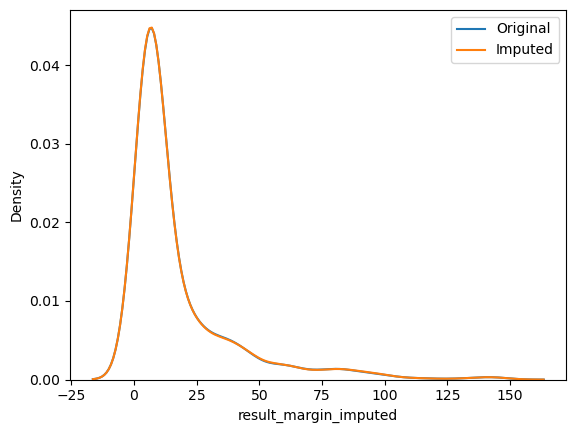

In [13]:
sns.distplot(df['result_margin'],label='Original',hist=False)
sns.distplot(df['result_margin_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [14]:
print('Original variable variance: ', df['result_margin'].var())
print('Variance after random imputation: ', df['result_margin_imputed'].var())

Original variable variance:  487.0154579188895
Variance after random imputation:  488.53576326235884


<Axes: >

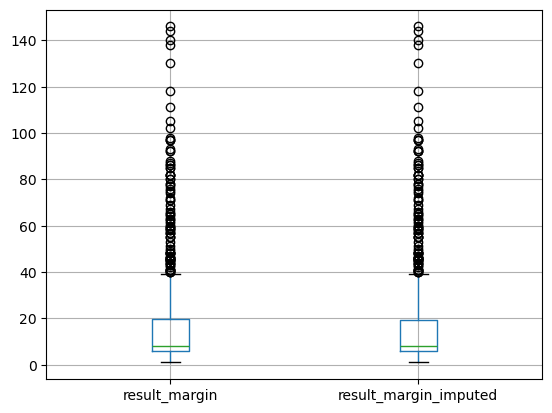

In [15]:
df[['result_margin', 'result_margin_imputed']].boxplot()